## Movie Recommender Comparison
### COMP 7118 - Course Project Demo Notebook
### Author: Tyler Howell

### Load & Split Data

In [ ]:
from data_preprocessing import load_data, leave_one_out_split

ratings, movies = load_data()

train_df, test_df = leave_one_out_split(ratings) #split data using leave-one-out 

print(train_df.head())
print(test_df.head())

       userId  movieId  rating   timestamp
10538      68     1101     3.5  1158533140
50207     325       80     4.0  1039397611
10484      68      628     3.5  1158534567
1574       16      293     4.0  1377477870
70108     448    99992     3.0  1374953846
       userId  movieId  rating   timestamp
67037     432    77866     4.5  1335139641
42175     288      474     3.0   978465565
93850     599     4351     3.0  1498524542
6187       42     2987     4.0   996262677
12229      75     1610     4.0  1158989841


## Build, Recommend, and Eval Popularity Baseline

In [ ]:
import pandas as pd
from models import build_popularity_baseline, recommend_popular_movies
from evaluate import eval_recommender

popularity_rankings = build_popularity_baseline(train_df, min_ratings=5) #build popularity baseline w/ training data, filter movies with <5 ratings

#recommendation function for eval - takes user_id and k, returns top-k recommendations
popular_recommend_func = lambda user_id, k: recommend_popular_movies(
    user_id=user_id,
    train_df=train_df,
    popularity_df=popularity_rankings,
    n=k)

#eval popularity baseline
popularity_results = eval_recommender(train_df=train_df, test_df=test_df,
    recommend_func=popular_recommend_func, model_name="Popularity Baseline", k=10)

results_df = pd.DataFrame([popularity_results])
print(results_df)

def show_recommendations(movie_ids, movies_df):
    return movies_df[movies_df["movieId"].isin(movie_ids)][["movieId", "title", "genres"]] #match movieIds to get titles/genres

user_id = ratings["userId"].iloc[0] #example user to show recommendations

rec_ids = recommend_popular_movies(user_id=user_id, train_df=train_df,
    popularity_df=popularity_rankings, n=10) #top 10 recs for example user

show_recommendations(rec_ids, movies)

                 Model  Precision@10  Recall@10  HitRate@10
0  Popularity Baseline      0.000164   0.001639    0.001639


,movieId,title,genres
796,1041,Secrets & Lies (1996),Drama
883,1178,Paths of Glory (1957),Drama|War
1426,1949,"Man for All Seasons, A (1966)",Drama
1664,2239,Swept Away (Travolti da un insolito destino ne...,Comedy|Drama
2582,3451,Guess Who's Coming to Dinner (1967),Drama
3210,4334,Yi Yi (2000),Drama
4396,6460,"Trial, The (Procès, Le) (1962)",Drama
5773,31364,Memories of Murder (Salinui chueok) (2003),Crime|Drama|Mystery|Thriller
8301,106642,"Day of the Doctor, The (2013)",Adventure|Drama|Sci-Fi
9618,177593,"Three Billboards Outside Ebbing, Missouri (2017)",Crime|Drama


## kNN

In [ ]:
from models import fit_item_knn, recommend_item_knn

user_item_matrix, item_neighbors = fit_item_knn(train_df=train_df, k_neighbors=20) #build user-item matrix and precompute item neighbors for KNN

example_user = ratings["userId"].iloc[0] #kNN recs for same example user

knn_rec_ids = recommend_item_knn(user_id=example_user, user_item_matrix=user_item_matrix, 
                                 item_neighbors=item_neighbors, n=10) #top 10 KNN recs for example user

show_recommendations(knn_rec_ids, movies)

,movieId,title,genres
693,911,Charade (1963),Comedy|Crime|Mystery|Romance|Thriller
1960,2599,Election (1999),Comedy
2119,2816,Iron Eagle II (1988),Action|War
2511,3359,Breaking Away (1979),Comedy|Drama
2996,4011,Snatch (2000),Comedy|Crime|Thriller
3771,5267,"Rookie, The (2002)",Drama
4338,6337,Owning Mahowny (2003),Crime|Drama|Thriller
4341,6341,"Shape of Things, The (2003)",Drama
4361,6378,"Italian Job, The (2003)",Action|Crime
4795,7143,"Last Samurai, The (2003)",Action|Adventure|Drama|War


In [ ]:
#eval for KNN
knn_recommend_func = lambda user_id, k: recommend_item_knn(
    user_id=user_id,
    user_item_matrix=user_item_matrix,
    item_neighbors=item_neighbors,
    n=k)

knn_results = eval_recommender(train_df=train_df, test_df=test_df, recommend_func=knn_recommend_func,
    model_name="Item-Item kNN", k=10)

knn_results

{'Model': 'Item-Item kNN',
 'Precision@10': 0.000819672131147541,
 'Recall@10': 0.00819672131147541,
 'HitRate@10': 0.00819672131147541}

### Train SVD & Recommend

In [ ]:
from models import fit_svd_model, recommend_svd

#first test of svd that gave init results
#svd_model = fit_svd_model(train_df=train_df, n_factors=50, n_epochs=20, 
#                          lr_all=0.005, reg_all=0.02, random_state=42)

#initialized with more factors and epochs to see if results improve
svd_model = fit_svd_model(train_df=train_df, n_factors=100, n_epochs=50, 
                          lr_all=0.005, reg_all=0.02, random_state=42) 

example_user = ratings["userId"].iloc[0] #SVD recs for same example user

svd_rec_ids = recommend_svd(user_id=example_user, train_df=train_df,
    movies_df=movies, model=svd_model, n=10)

show_recommendations(svd_rec_ids, movies)

,movieId,title,genres
15,16,Casino (1995),Crime|Drama
31,32,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),Mystery|Sci-Fi|Thriller
55,62,Mr. Holland's Opus (1995),Drama
152,180,Mallrats (1995),Comedy|Romance
613,778,Trainspotting (1996),Comedy|Crime|Drama
698,916,Roman Holiday (1953),Comedy|Drama|Romance
709,928,Rebecca (1940),Drama|Mystery|Romance|Thriller
733,953,It's a Wonderful Life (1946),Children|Drama|Fantasy|Romance
819,1079,"Fish Called Wanda, A (1988)",Comedy|Crime
929,1228,Raging Bull (1980),Drama


In [ ]:
#eval for SVD
svd_recommend_func = lambda user_id, k: recommend_svd(
    user_id=user_id,
    train_df=train_df,
    movies_df=movies,
    model=svd_model,
    n=k) 

svd_results = eval_recommender(train_df=train_df, test_df=test_df,
    recommend_func=svd_recommend_func, model_name="SVD (100 factors)", k=10)

svd_results

{'Model': 'SVD (100 factors)',
 'Precision@10': 0.001967213114754099,
 'Recall@10': 0.019672131147540985,
 'HitRate@10': 0.019672131147540985}

### Popularity Sampled Score Function

In [ ]:
def score_popularity_candidates(user_id, candidates):
    ranked = popularity_rankings[popularity_rankings["movieId"].isin(candidates)]
    return ranked["movieId"].tolist()

### Evaluate Popularity

In [ ]:
from evaluate import eval_recommender_sampled

#eval w/ sampled candidates for popularity baseline
popularity_results = eval_recommender_sampled(train_df=train_df, test_df=test_df, movies_df=movies,
                                              score_func=score_popularity_candidates, model_name="Popularity Baseline", k=10, n_neg=100)

### Knn Sampled Score Function

In [ ]:
from models import score_user_items_knn
#scoring for knn eval
def score_knn_candidates(user_id, candidates):
    scores = score_user_items_knn(user_id=user_id, user_item_matrix=user_item_matrix,
        item_neighbors=item_neighbors)

    candidate_scores = scores[scores.index.isin(candidates)] #filter to just candidates
    missing_candidates = [item for item in candidates if item not in candidate_scores.index] #handle any missing
    ranked_items = candidate_scores.sort_values(ascending=False).index.tolist() #rank by score

    return ranked_items + missing_candidates

### Evaluate 

In [ ]:
#eval w/ sampled candidates for KNN
knn_results = eval_recommender_sampled(train_df=train_df, test_df=test_df,movies_df=movies, 
                                       score_func=score_knn_candidates, model_name="Item-Item kNN", k=10,n_neg=100)

### SVD Sampled Score Function

In [ ]:
def score_svd_candidates(user_id, candidates):
    predictions = []

    #gen predictions for candidates using SVD model
    for movie_id in candidates:
        pred = svd_model.predict(user_id, movie_id).est
        predictions.append((movie_id, pred))

    predictions.sort(key=lambda x: x[1], reverse=True) #sort by predicted score

    return [movie_id for movie_id, score in predictions]

### Evaluate

In [ ]:
#eval w/ sampled candidates for SVD
svd_results = eval_recommender_sampled(train_df=train_df, test_df=test_df, movies_df=movies, 
                                       score_func=score_svd_candidates, model_name="SVD", k=10, n_neg=100)

### Combining Results:

In [15]:
results_df = pd.DataFrame([popularity_results, knn_results, svd_results])
results_df

,Model,Precision@10,Recall@10,HitRate@10,Evaluation
0,Popularity Baseline,0.041967,0.419672,0.419672,Sampled Candidates (100 negatives)
1,Item-Item kNN,0.063770,0.637705,0.637705,Sampled Candidates (100 negatives)
2,SVD,0.032787,0.327869,0.327869,Sampled Candidates (100 negatives)


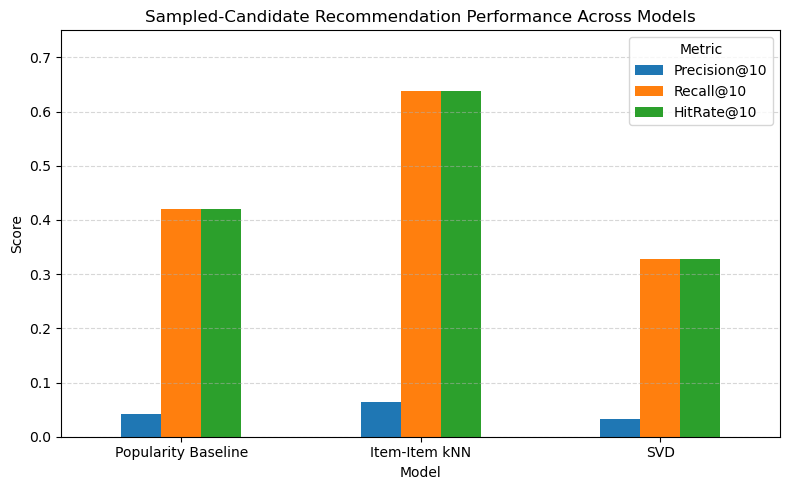

In [16]:
import matplotlib.pyplot as plt

metrics = ["Precision@10", "Recall@10", "HitRate@10"]
plot_df = results_df.set_index("Model")[metrics]

#grouped bar chart
ax = plot_df.plot(kind="bar", figsize=(8, 5), rot=0)

plt.title("Sampled-Candidate Recommendation Performance Across Models")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 0.75)
plt.legend(title="Metric")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()

plt.savefig("sampled_candidate_model_comparison.png", dpi=300, bbox_inches="tight")

plt.show()